In [1]:
import os
import sys
sys.path.append("../..")

import pandas as pd
import numpy as np

from pipelines.utils import DATASET_NAME, ROOT_DIR, TRAIN_CONFIG_KEYS, load_road_network
from preprocessing.utils import create_edge_emb_mapping, generate_speed_features


In [ ]:
city_name = "cd"

# load traj dataset and network
df = pd.read_parquet(os.path.join(ROOT_DIR,"datasets/trajectory/porto/train/train_123.parquet"))
edge_df, _, _, LG = load_road_network(city_name=city_name)
edge_df = edge_df.drop(columns=['highway_enc']) # We cannot safe this, as we create it each time we lead the network

In [ ]:
speed_df = generate_speed_features(df, edge_df)

In [ ]:
df_merged = pd.merge(edge_df, speed_df[['util','avg_speed']], left_index=True, right_index=True)

In [ ]:
# in edge_df set all avg_speed which are below 10 to 10
# Reasons are: 
# 1. We had 0 values which screwed the training, because we calculated the travel time by dividing the length by the avg_speed, thus got some inf numbers
# 2. Does it make sense that we have avg speed below 10?
df_merged.loc[df_merged['avg_speed'] < 10, 'avg_speed'] = 10

In [ ]:
# Save new edge_df
#df.to_file(os.path.join(ROOT_DIR, f"datasets/osm/{city_name}/edges.shp"), driver='ESRI Shapefile')
# Shouldnt that be the df_merged?

#### Avg Speed NaN values

In [4]:
contains_nan = edge_df['avg_speed'].isnull().values.any()
print(f"Does the DataFrame contain NaN values? {contains_nan}")

Does the DataFrame contain NaN values? True


In [12]:
mask = edge_df['avg_speed'].isnull()
nan_rows = edge_df[mask]

nan_rows

,,,osmid,oneway,highway,length,lanes,ref,maxspeed,bridge,name,width,access,junction,tunnel,area,fid,util,avg_speed,geometry
u,v,key,,,,,,,,,,,,,,,,,,
112628026,296060854,0,1016542176,1,primary,41.334,2,EN 12,50,NaN,Estrada Exterior da Circunvalação,NaN,NaN,NaN,NaN,NaN,391,0,NaN,"LINESTRING (-8.64621 41.18277, -8.64633 41.182..."
114310705,25507600,0,12543140,1,motorway_link,290.395,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,429,0,NaN,"LINESTRING (-8.58151 41.14802, -8.58149 41.147..."
312403572,497181910,0,40860055,0,residential,108.423,NaN,NaN,NaN,NaN,Rua do Alfageme de Santarém,NaN,NaN,NaN,NaN,NaN,1551,0,NaN,"LINESTRING (-8.67599 41.16063, -8.67590 41.160..."
314536449,314536503,0,"[185967400, 362138137, 362138138]",1,motorway,977.037,2,A 43,NaN,yes,Radial de Gondomar,NaN,NaN,NaN,NaN,NaN,1722,0,NaN,"LINESTRING (-8.54884 41.15205, -8.54918 41.152..."
314536503,112618358,0,95163014,1,motorway_link,289.927,1,NaN,NaN,NaN,Nó de Areias / Circunvalação,NaN,NaN,NaN,NaN,NaN,1723,0,NaN,"LINESTRING (-8.55862 41.15625, -8.55878 41.156..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8391190797,8391190786,0,903471404,0,unclassified,287.696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11091,0,NaN,"LINESTRING (-8.65322 41.16374, -8.65330 41.163..."
8421298946,2165720706,0,906902688,0,residential,3.659,NaN,NaN,NaN,NaN,Praceta Eduardo Soares,NaN,NaN,NaN,NaN,NaN,11128,0,NaN,"LINESTRING (-8.66298 41.17489, -8.66294 41.17489)"
8423221829,8423221829,1,547105687,0,residential,56.558,NaN,NaN,NaN,NaN,Praceta Ribeiro Sanches,NaN,NaN,NaN,NaN,NaN,11133,0,NaN,"LINESTRING (-8.66369 41.17513, -8.66373 41.174..."


In [14]:
df = edge_df.copy()
# Calculate the mean avg_speed for each highway
mean_speeds = df.groupby('highway')['avg_speed'].mean()

# Fill NaN values in the avg_speed column based on the highway column
df['avg_speed'] = df.apply(
    lambda row: mean_speeds[row['highway']] if pd.isnull(row['avg_speed']) else row['avg_speed'],
    axis=1
)

df


                                                     osmid  oneway  \
u          v          key                                            
25503936   4722746638 0                          479127843       1   
           281726624  0                            4256507       1   
25503951   1243857957 0                            4256513       1   
           4507024043 0                          158906049       1   
25504027   1243857999 0    [4256491, 108390772, 479127839]       1   
...                                                    ...     ...   
9681200397 114320445  0                         1016537009       1   
9681208879 1143317642 0             [161124098, 161124196]       1   
           1731168950 0                         1018551330       1   
9706839841 1107381202 0                           41097169       0   
9709007543 415754684  0                         1056607115       0   

                                 highway   length       lanes    ref maxspeed  \
u       

##### Small AVG Speed 

In [ ]:
# get the columns where average speed is 0
zero_speed = edge_df.loc[edge_df['avg_speed'] < 10]

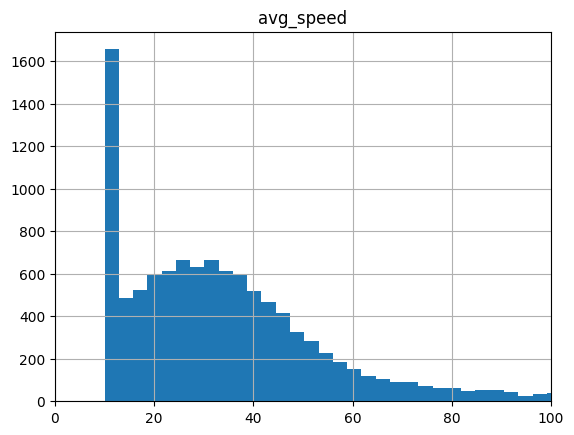

In [3]:
# Analyse avg_speed
import pandas as pd
import matplotlib.pyplot as plt

# Plot the histogram of the 'avg_speed' column
edge_df.hist(column='avg_speed', bins=200)

# Set the range of the x-axis
plt.xlim(0, 100)

# Show the plot
plt.show()